# SAM3

In [1]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e .

Cloning into 'sam3'...
remote: Enumerating objects: 1393, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 1393 (delta 16), reused 21 (delta 8), pack-reused 1270 (from 3)
Receiving objects: 100% (1393/1393), 60.88 MiB | 19.88 MiB/s, done.
Resolving deltas: 100% (438/438), done.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
%cd sam3

/content/sam3


In [2]:
#from https://qiita.com/miso_taku/items/688dd439304e00c543ef
!pip install -e ".[notebooks]"

Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 107.5 MB

In [3]:
!pip install einops ninja && pip install flash-attn-3 --no-deps --index-url https://download.pytorch.org/whl/cu128
!pip install git+https://github.com/ronghanghu/cc_torch.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.0 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.2/442.2 MB 3.8 MB/s eta 0:00:00
  Cloning https://github.com/ronghanghu/cc_torch.git to /tmp/pip-req-build-8owf2o6a
  Running command git clone --filter=blob:none --quiet https://github.com/ronghanghu/cc_torch.git /tmp/pip-req-build-8owf2o6a
  Resolved https://github.com/ronghanghu/cc_torch.git to commit 446e9360ed10d3c8d03925ccb5f220ccb62009de
  Preparing metadata (setup.py) ... done
  Created wheel for cc_torch: filename=cc_torch-0.2-cp312-cp312-linux_x86_64.whl size=326125 sha256=f255706d639496e501af9b568bb2e377410954bd25ba46061cee43288c89d09f
  Stored in directory: /tmp/pip-ephem-wheel-cache-20obwee5/wheels/9b/52/26/1d2aab440cc06502e72714c5658b5fc7caf1c0fc538916074a
Successfully built cc_torch


In [4]:
#https://dev.to/0xkoji/huggingface-login-on-google-colab-54ek
from huggingface_hub import login
from google.colab import userdata
HF_TOKEN=userdata.get('HF_TOKEN')

if HF_TOKEN:
    login(HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("Token is not set. Please save the token first.")

Successfully logged in to Hugging Face!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
#Import modueles
import matplotlib.pyplot as plt


In [6]:
#https://github.com/facebookresearch/sam3/blob/main/examples/sam3_image_predictor_example.ipynb
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [7]:
import torch
#################################### For Image ####################################
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
# Load the model
model = build_sam3_image_model()
processor = Sam3Processor(model)


/content/sam3/sam3/model/model_misc.py:71: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

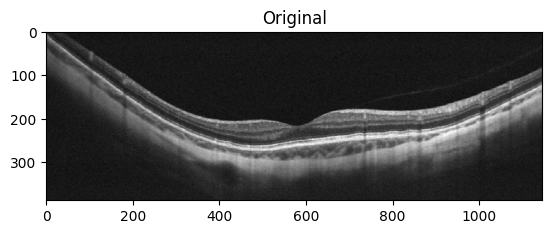

In [27]:
# Load an image
image_path="/content/drive/MyDrive/ML-OCT_project_datasets/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/NO/no_1153297_1.jpg"
image = Image.open(image_path)
inference_state = processor.set_image(image)

plt.imshow(image)
plt.title("Original")
plt.show()

In [42]:
# Prompt the model with text
text_prompt = ""
output = processor.set_text_prompt(state=inference_state, prompt=text_prompt)

# Get the masks, bounding boxes, and scores
masks, boxes, scores = output["masks"], output["boxes"], output["scores"]

found 0 object(s)


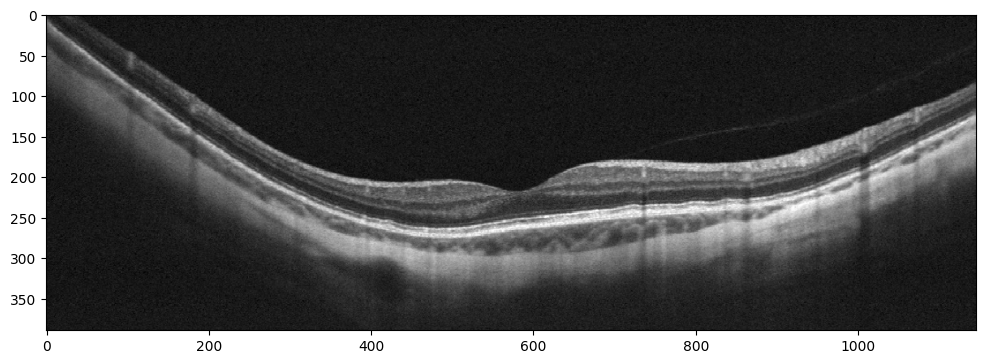

In [43]:
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results
#https://github.com/facebookresearch/sam3/blob/main/examples/sam3_image_predictor_example.ipynb
img0 = Image.open(image_path)
plot_results(img0, inference_state)